#Problem Statement: AI-Driven Employee Attrition Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
from sklearn.ensemble import AdaBoostClassifier
from imblearn.over_sampling import SMOTE

In [2]:
filepath='/content/employee_attrition_dataset.csv'
emply_df=pd.read_csv(filepath)
emply_df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No


In [3]:
emply_df.copy()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,27,Female,Divorced,HR,Analyst,2,4172,76,24,...,No,4,46,10,3,1,4,24,4,No
996,997,47,Male,Single,IT,Manager,4,11007,71,19,...,Yes,7,36,16,3,2,4,39,3,Yes
997,998,50,Female,Divorced,IT,Executive,1,4641,43,25,...,Yes,1,46,9,2,3,3,33,2,No
998,999,28,Female,Married,HR,Executive,4,19855,92,13,...,No,4,52,17,4,1,4,41,4,No


##1.Business Understanding


####Understand the attrition problem
#####Employee attrition refers to employees leaving the organization due to resignation, retirement, or other reasons. High attrition rates can negatively affect company performance by increasing recruitment costs, reducing productivity, and causing project delays.

####Explain why employee retention is important  

#####Employee retention is important because employees are one of the most valuable assets of an organization. Retaining skilled and experienced employees helps companies maintain productivity, reduce operational costs, and achieve long-term business success.


####Identify possible business impact of attrition
#####Employee attrition can create several negative effects on an organization’s performance, productivity, and profitability.Therefore, organizations should use data-driven approaches and employee retention strategies to identify high-risk employees early and minimize attrition.
#####1.Financial Loss
#####2.Difficulty In Achieving Business Goals
#####3.Increased Workload for Existing Employees
#####4.Project Delays


##2.Data Understanding

###Dataset Exploration

In [4]:
emply_df.head(10)

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No
5,6,58,Male,Divorced,Finance,Assistant,3,16746,48,15,...,No,9,35,9,2,2,3,24,1,No
6,7,38,Male,Divorced,HR,Analyst,1,18995,55,29,...,No,2,55,13,1,1,3,40,2,No
7,8,42,Female,Divorced,Marketing,Manager,3,19035,24,4,...,No,5,46,12,4,2,4,13,1,No
8,9,30,Male,Married,IT,Analyst,5,14671,31,18,...,Yes,2,36,8,3,4,2,48,3,No
9,10,30,Male,Married,Marketing,Analyst,3,16210,31,18,...,No,7,53,5,3,3,4,39,2,No


In [5]:
emply_df.tail(10)

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
990,991,31,Male,Single,HR,Analyst,3,3534,23,26,...,Yes,4,38,9,4,4,3,39,4,No
991,992,55,Female,Married,HR,Manager,1,6364,63,21,...,No,8,42,8,1,2,2,33,2,Yes
992,993,23,Male,Single,Finance,Executive,2,6342,47,5,...,Yes,8,37,1,2,2,4,38,4,No
993,994,24,Male,Divorced,Finance,Manager,2,16465,32,10,...,Yes,7,51,18,2,2,3,8,4,No
994,995,56,Male,Single,HR,Manager,1,7500,23,6,...,Yes,9,39,16,3,1,4,49,1,No
995,996,27,Female,Divorced,HR,Analyst,2,4172,76,24,...,No,4,46,10,3,1,4,24,4,No
996,997,47,Male,Single,IT,Manager,4,11007,71,19,...,Yes,7,36,16,3,2,4,39,3,Yes
997,998,50,Female,Divorced,IT,Executive,1,4641,43,25,...,Yes,1,46,9,2,3,3,33,2,No
998,999,28,Female,Married,HR,Executive,4,19855,92,13,...,No,4,52,17,4,1,4,41,4,No
999,1000,48,Female,Divorced,IT,Analyst,2,11738,39,1,...,Yes,2,59,5,1,4,3,43,2,No


In [6]:
emply_df.shape

(1000, 26)

In [7]:
emply_df.columns

Index(['Employee_ID', 'Age', 'Gender', 'Marital_Status', 'Department',
       'Job_Role', 'Job_Level', 'Monthly_Income', 'Hourly_Rate',
       'Years_at_Company', 'Years_in_Current_Role',
       'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction',
       'Performance_Rating', 'Training_Hours_Last_Year', 'Overtime',
       'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism',
       'Work_Environment_Satisfaction', 'Relationship_with_Manager',
       'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked',
       'Attrition'],
      dtype='object')

In [8]:
emply_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    1000 non-null   int64 
 1   Age                            1000 non-null   int64 
 2   Gender                         1000 non-null   object
 3   Marital_Status                 1000 non-null   object
 4   Department                     1000 non-null   object
 5   Job_Role                       1000 non-null   object
 6   Job_Level                      1000 non-null   int64 
 7   Monthly_Income                 1000 non-null   int64 
 8   Hourly_Rate                    1000 non-null   int64 
 9   Years_at_Company               1000 non-null   int64 
 10  Years_in_Current_Role          1000 non-null   int64 
 11  Years_Since_Last_Promotion     1000 non-null   int64 
 12  Work_Life_Balance              1000 non-null   int64 
 13  Job_

In [9]:
emply_df.dtypes

,0
Employee_ID,int64
Age,int64
Gender,object
Marital_Status,object
Department,object
Job_Role,object
Job_Level,int64
Monthly_Income,int64
Hourly_Rate,int64
Years_at_Company,int64


###Missing Value Analysis

In [10]:
emply_df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Marital_Status,0
Department,0
Job_Role,0
Job_Level,0
Monthly_Income,0
Hourly_Rate,0
Years_at_Company,0


There is no missing value in the dataset

###Datatype Analysis

In [11]:
emply_df.dtypes

,0
Employee_ID,int64
Age,int64
Gender,object
Marital_Status,object
Department,object
Job_Role,object
Job_Level,int64
Monthly_Income,int64
Hourly_Rate,int64
Years_at_Company,int64


In [12]:
emply_df.dtypes.value_counts()

,count
int64,20
object,6


In [13]:
emply_df.columns

Index(['Employee_ID', 'Age', 'Gender', 'Marital_Status', 'Department',
       'Job_Role', 'Job_Level', 'Monthly_Income', 'Hourly_Rate',
       'Years_at_Company', 'Years_in_Current_Role',
       'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction',
       'Performance_Rating', 'Training_Hours_Last_Year', 'Overtime',
       'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism',
       'Work_Environment_Satisfaction', 'Relationship_with_Manager',
       'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked',
       'Attrition'],
      dtype='object')

In [14]:
num_cols=[column for column in emply_df.columns if emply_df[column].dtypes !='O']

In [15]:
num_cols

['Employee_ID',
 'Age',
 'Job_Level',
 'Monthly_Income',
 'Hourly_Rate',
 'Years_at_Company',
 'Years_in_Current_Role',
 'Years_Since_Last_Promotion',
 'Work_Life_Balance',
 'Job_Satisfaction',
 'Performance_Rating',
 'Training_Hours_Last_Year',
 'Project_Count',
 'Average_Hours_Worked_Per_Week',
 'Absenteeism',
 'Work_Environment_Satisfaction',
 'Relationship_with_Manager',
 'Job_Involvement',
 'Distance_From_Home',
 'Number_of_Companies_Worked']

In [16]:
emply_df[num_cols]

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
0,1,58,1,15488,28,15,4,2,1,3,4,14,6,54,17,4,4,4,20,3
1,2,48,5,13079,28,6,9,1,2,1,1,6,2,45,1,4,1,2,25,2
2,3,34,1,13744,24,24,14,8,3,2,1,77,6,34,2,3,4,4,45,3
3,4,27,1,6809,26,10,8,2,3,5,4,49,9,48,18,2,3,1,35,3
4,5,40,1,10206,52,29,10,1,2,5,1,64,3,33,0,4,1,3,44,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,27,2,4172,76,24,14,3,4,5,4,76,4,46,10,3,1,4,24,4
996,997,47,4,11007,71,19,6,0,3,1,1,53,7,36,16,3,2,4,39,3
997,998,50,1,4641,43,25,12,3,4,1,1,7,1,46,9,2,3,3,33,2
998,999,28,4,19855,92,13,13,0,2,2,2,54,4,52,17,4,1,4,41,4


In [17]:
cat_col=[column for column in emply_df.columns if emply_df[column].dtypes =='O']

In [18]:
cat_col

['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime', 'Attrition']

In [19]:
emply_df[cat_col]

,Gender,Marital_Status,Department,Job_Role,Overtime,Attrition
0,Female,Married,IT,Manager,No,No
1,Female,Married,Sales,Assistant,Yes,No
2,Male,Married,Marketing,Assistant,Yes,No
3,Female,Divorced,Marketing,Manager,No,No
4,Male,Divorced,Marketing,Executive,No,No
...,...,...,...,...,...,...
995,Female,Divorced,HR,Analyst,No,No
996,Male,Single,IT,Manager,Yes,Yes
997,Female,Divorced,IT,Executive,Yes,No
998,Female,Married,HR,Executive,No,No


###Duplicate checking

In [20]:
emply_df.duplicated().sum()

np.int64(0)

There is no duplicated values in the dataset

###Statistical Summary

Statistical summary for numerical columns

In [21]:
emply_df.describe()

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,39.991000,3.055000,11499.899000,57.837000,14.922000,7.539000,4.40800,2.495000,3.151000,2.52700,50.043000,4.877000,44.553000,9.524000,2.494000,2.519000,2.503000,24.507000,2.484000
std,288.819436,11.780055,1.399977,4920.529231,24.702037,8.350548,4.001061,2.99508,1.105077,1.426967,1.13073,28.204657,2.546833,8.704192,5.973534,1.110494,1.106736,1.099636,14.138099,1.111296
min,1.000000,20.000000,1.000000,3001.000000,15.000000,1.000000,1.000000,0.00000,1.000000,1.000000,1.00000,0.000000,1.000000,30.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,250.750000,30.000000,2.000000,7395.750000,36.000000,8.000000,4.000000,2.00000,2.000000,2.000000,2.00000,26.000000,3.000000,37.000000,4.000000,2.000000,2.000000,2.000000,12.000000,1.000000
50%,500.500000,41.000000,3.000000,11256.000000,58.000000,15.000000,8.000000,4.00000,3.000000,3.000000,3.00000,50.000000,5.000000,45.000000,9.000000,2.000000,3.000000,3.000000,24.000000,2.000000
75%,750.250000,50.250000,4.000000,15855.000000,80.000000,22.000000,11.000000,7.00000,3.000000,4.000000,4.00000,75.250000,7.000000,52.000000,15.000000,4.000000,4.000000,3.000000,37.000000,3.000000
max,1000.000000,59.000000,5.000000,19999.000000,99.000000,29.000000,14.000000,9.00000,4.000000,5.000000,4.00000,99.000000,9.000000,59.000000,19.000000,4.000000,4.000000,4.000000,49.000000,4.000000


Statistical summary for categorical columns

In [22]:
emply_df.describe(include='object')

,Gender,Marital_Status,Department,Job_Role,Overtime,Attrition
count,1000,1000,1000,1000,1000,1000
unique,2,3,5,4,2,2
top,Male,Married,Finance,Manager,No,No
freq,516,348,218,268,512,811


In [23]:
emply_df.nunique()

,0
Employee_ID,1000
Age,40
Gender,2
Marital_Status,3
Department,5
Job_Role,4
Job_Level,5
Monthly_Income,971
Hourly_Rate,85
Years_at_Company,29


##3.Exploratory Data Analysis(EDA)

In [24]:
emply_df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No


In [25]:
emply_df['Attrition'].value_counts()

,count
Attrition,
No,811
Yes,189


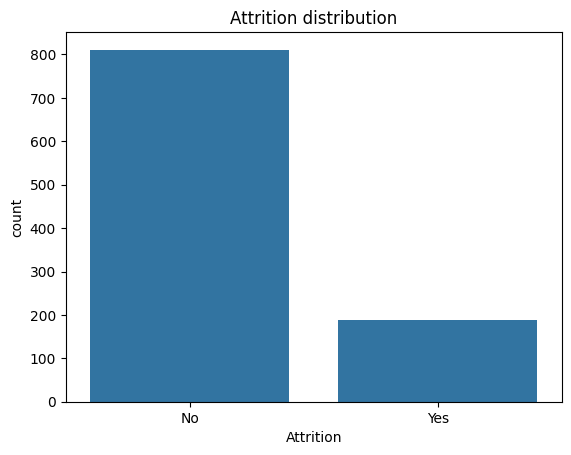

In [26]:
sns.countplot(x='Attrition',data=emply_df)
plt.title('Attrition distribution')
plt.show()

The visual shows that the number of employee whos stayed the organization is higher than the number of the employee who left the organization.So its indicates it better employee retention.

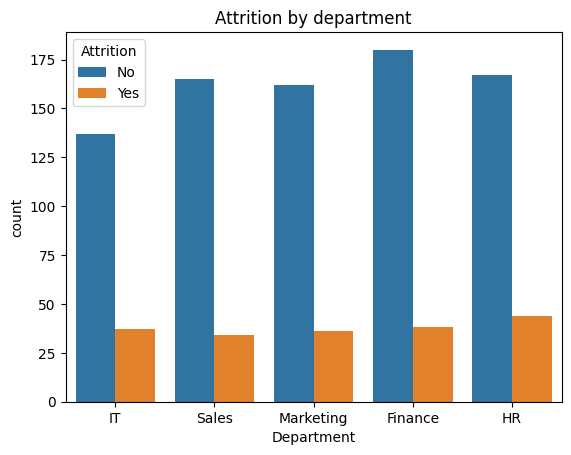

In [27]:
sns.countplot(x='Department', hue='Attrition',data=emply_df)
plt.title('Attrition by department')
plt.show()

So its shows that HR department has more people who want to left the organization.And the Finance and IT department show the strongest retention levels,with very low attrition counts relative to their total ratio

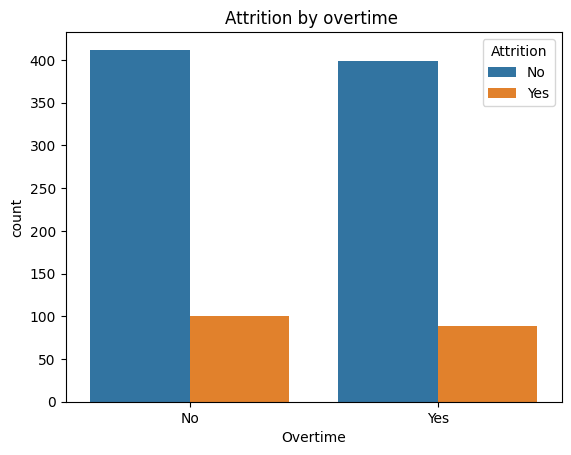

In [28]:
sns.countplot(x='Overtime', hue='Attrition',data=emply_df)
plt.title('Attrition by overtime ')
plt.show()

Employees without overtime show slightly higher attrition compared to employees working overtime.
However, in both overtime categories, the number of employees staying is significantly higher than those leaving.
This indicates that overtime alone may not be the major factor influencing employee attrition in this organization.

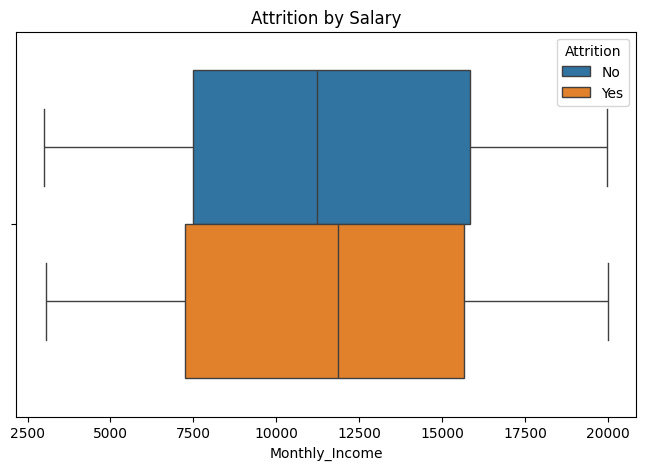

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Monthly_Income', hue='Attrition',data=emply_df)
plt.title('Attrition by Salary')
plt.show()

This shows employees who want stayed and left the oraganization are comparitively equal salaries and few of are high salary those are employee who want to stay.Most attrition among lower paid employees also some high earning employees are leaving.

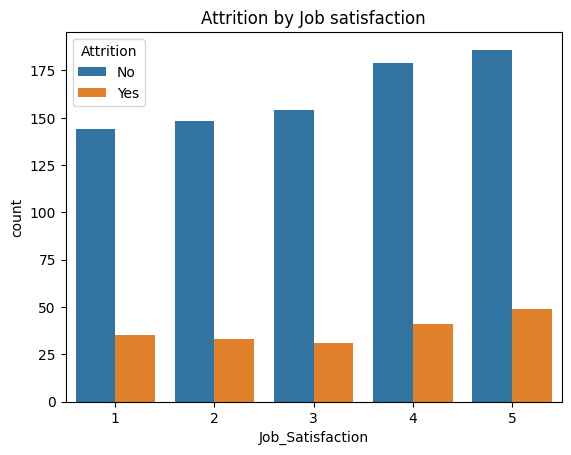

In [30]:
sns.countplot(x='Job_Satisfaction', hue='Attrition',data=emply_df)
plt.title('Attrition by Job satisfaction')
plt.show()

Employees with lower job statisfaction are more likrly to leave and employees with higher job satisfaction levels also show a slightly higher number of attrition cases. ,it indicates the employee who enageged with job can reduce resignation.

In [31]:
corr = emply_df.corr(numeric_only=True)

corr

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
Employee_ID,1.000000,-0.012222,-0.013340,-0.045417,0.040863,-0.001709,-0.032868,-0.034913,-0.016545,-0.020782,0.006935,0.006736,-0.031376,-0.064954,0.054185,-0.047742,0.014163,0.078447,-0.032465,-0.002367
Age,-0.012222,1.000000,-0.074931,-0.020251,0.019844,0.016234,-0.012895,-0.025487,0.015798,-0.069234,0.022826,-0.030696,0.038766,-0.000498,-0.006846,0.014190,0.030303,0.004214,-0.005220,0.010885
Job_Level,-0.013340,-0.074931,1.000000,0.036941,0.038381,-0.021553,-0.034784,0.034033,-0.011792,-0.046251,-0.006314,-0.005739,0.010883,-0.020160,0.039282,-0.025220,-0.017796,-0.033594,-0.004849,-0.007476
Monthly_Income,-0.045417,-0.020251,0.036941,1.000000,-0.056088,-0.045316,-0.003193,-0.025036,-0.005465,0.011808,-0.027322,0.005971,-0.018164,-0.045374,-0.009032,-0.010991,-0.037506,0.019958,-0.050925,0.053809
Hourly_Rate,0.040863,0.019844,0.038381,-0.056088,1.000000,-0.024160,0.011534,-0.006745,0.033651,-0.003476,-0.017170,-0.039236,-0.017837,0.024279,-0.010878,0.049720,-0.007924,-0.053508,-0.040329,-0.073225
Years_at_Company,-0.001709,0.016234,-0.021553,-0.045316,-0.024160,1.000000,0.013453,-0.068006,-0.005791,-0.003631,-0.021191,0.045070,0.024353,0.000539,-0.055268,0.037622,-0.008288,-0.003572,0.020777,-0.031632
Years_in_Current_Role,-0.032868,-0.012895,-0.034784,-0.003193,0.011534,0.013453,1.000000,0.013122,-0.012408,-0.012516,0.017468,-0.032618,0.005334,-0.019375,0.020671,0.007375,-0.000846,-0.001164,0.026309,0.019164
Years_Since_Last_Promotion,-0.034913,-0.025487,0.034033,-0.025036,-0.006745,-0.068006,0.013122,1.000000,-0.052914,-0.028248,-0.004438,0.004615,0.002649,0.002510,-0.025501,0.007659,0.010644,0.023031,0.024872,0.028729
Work_Life_Balance,-0.016545,0.015798,-0.011792,-0.005465,0.033651,-0.005791,-0.012408,-0.052914,1.000000,0.003971,0.001710,0.035383,0.011696,-0.026093,0.047860,-0.006958,0.005807,0.029667,-0.045743,-0.011884
Job_Satisfaction,-0.020782,-0.069234,-0.046251,0.011808,-0.003476,-0.003631,-0.012516,-0.028248,0.003971,1.000000,-0.002840,-0.028266,-0.026009,-0.023332,0.059172,-0.030696,-0.050941,-0.015918,0.022995,0.012572


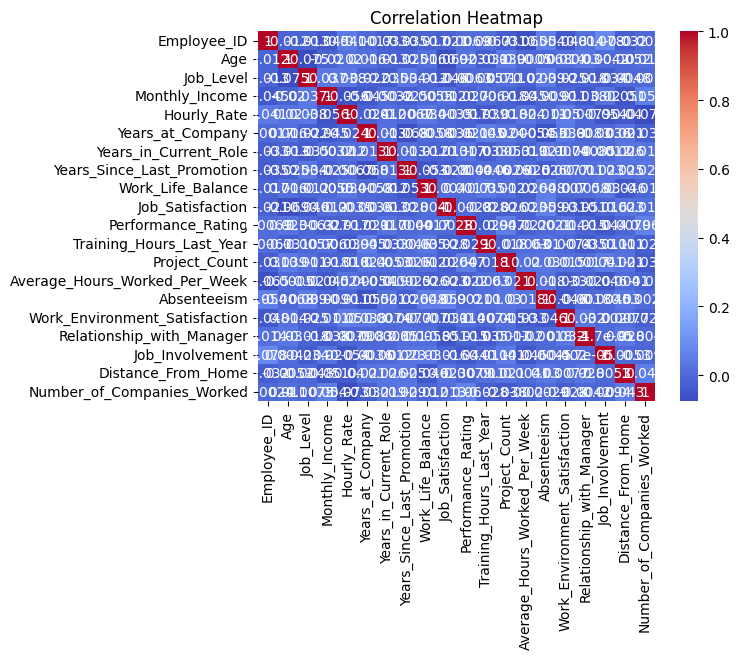

In [32]:
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Correlation helps identify important factors affecting attrition.The heatmap shows mostly weak to moderate coorelation among features.Job_level and Montly_Income have strong positive correlation.

##4. Data Preprocessing

###Handling missing value

In [33]:
emply_df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Marital_Status,0
Department,0
Job_Role,0
Job_Level,0
Monthly_Income,0
Hourly_Rate,0
Years_at_Company,0


In [34]:
emply_df.isnull().sum().sum()

np.int64(0)

TO confirm there is no missing values, so there is no need to perform handling missing values.

###Encoding Categorical variables

In [35]:
emply_df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No


In [36]:
emply_df.drop('Employee_ID', axis=1,inplace=True)

In [37]:
emply_df.head()

,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,58,Female,Married,IT,Manager,1,15488,28,15,4,...,No,6,54,17,4,4,4,20,3,No
1,48,Female,Married,Sales,Assistant,5,13079,28,6,9,...,Yes,2,45,1,4,1,2,25,2,No
2,34,Male,Married,Marketing,Assistant,1,13744,24,24,14,...,Yes,6,34,2,3,4,4,45,3,No
3,27,Female,Divorced,Marketing,Manager,1,6809,26,10,8,...,No,9,48,18,2,3,1,35,3,No
4,40,Male,Divorced,Marketing,Executive,1,10206,52,29,10,...,No,3,33,0,4,1,3,44,3,No


In [38]:
emply_df.dtypes

,0
Age,int64
Gender,object
Marital_Status,object
Department,object
Job_Role,object
Job_Level,int64
Monthly_Income,int64
Hourly_Rate,int64
Years_at_Company,int64
Years_in_Current_Role,int64


In [39]:
cat_col=[column for column in emply_df.columns if emply_df[column].dtypes =='O']

In [40]:
cat_col

['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime', 'Attrition']

In [41]:
emply_df[cat_col]

,Gender,Marital_Status,Department,Job_Role,Overtime,Attrition
0,Female,Married,IT,Manager,No,No
1,Female,Married,Sales,Assistant,Yes,No
2,Male,Married,Marketing,Assistant,Yes,No
3,Female,Divorced,Marketing,Manager,No,No
4,Male,Divorced,Marketing,Executive,No,No
...,...,...,...,...,...,...
995,Female,Divorced,HR,Analyst,No,No
996,Male,Single,IT,Manager,Yes,Yes
997,Female,Divorced,IT,Executive,Yes,No
998,Female,Married,HR,Executive,No,No


In [42]:
le = LabelEncoder()
for col in emply_df.select_dtypes(include='object').columns:
  emply_df[col]=le.fit_transform(emply_df[col])

In [43]:
emply_df[cat_col].head()

,Gender,Marital_Status,Department,Job_Role,Overtime,Attrition
0,0,1,2,3,0,0
1,0,1,4,1,1,0
2,1,1,3,1,1,0
3,0,0,3,3,0,0
4,1,0,3,2,0,0


In [44]:
emply_df[cat_col].tail()

,Gender,Marital_Status,Department,Job_Role,Overtime,Attrition
995,0,0,1,0,0,0
996,1,2,2,3,1,1
997,0,0,2,2,1,0
998,0,1,1,2,0,0
999,0,0,2,0,1,0


###Feature scaling

In [45]:
from sklearn.preprocessing import StandardScaler

In [46]:
scaling_cols=['Age','Job_Level','Monthly_Income','Hourly_Rate','Years_at_Company','Years_in_Current_Role','Years_Since_Last_Promotion','Work_Life_Balance',
              'Job_Satisfaction','Performance_Rating','Training_Hours_Last_Year','Project_Count','Average_Hours_Worked_Per_Week','Absenteeism','Work_Environment_Satisfaction',
              'Relationship_with_Manager','Job_Involvement','Distance_From_Home','Number_of_Companies_Worked']

In [47]:
scaling = StandardScaler()

In [48]:
emply_df[scaling_cols]=scaling.fit_transform(emply_df[scaling_cols])

In [49]:
emply_df.head()

,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1.529535,0,1,2,3,-1.468616,0.810908,-1.208480,0.009345,-0.884958,...,0,0.441160,1.085882,1.252147,1.356832,1.338839,1.362040,-0.318944,0.464555,0
1,0.680218,0,1,4,1,1.390004,0.321082,-1.208480,-1.068968,0.365336,...,1,-1.130204,0.051380,-1.427675,1.356832,-1.373192,-0.457653,0.034888,-0.435745,0
2,-0.508826,1,1,3,1,-1.468616,0.456297,-1.370491,1.087658,1.615630,...,1,0.441160,-1.213011,-1.260186,0.455881,1.338839,1.362040,1.450213,0.464555,0
3,-1.103348,0,0,3,3,-1.468616,-0.953809,-1.289486,-0.589717,0.115277,...,0,1.619683,0.396214,1.419636,-0.445070,0.434829,-1.367499,0.742550,0.464555,0
4,0.000764,1,0,3,2,-1.468616,-0.263091,-0.236415,1.686721,0.615395,...,0,-0.737363,-1.327956,-1.595164,1.356832,-1.373192,0.452194,1.379447,0.464555,0


###Train-Test splitting

In [50]:
#split dataset into target and features
y=emply_df['Attrition']
X=emply_df.drop(['Attrition'], axis=1)

In [51]:
y.head()

,Attrition
0,0
1,0
2,0
3,0
4,0


In [52]:
X.head()

,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,...,Training_Hours_Last_Year,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
0,1.529535,0,1,2,3,-1.468616,0.810908,-1.208480,0.009345,-0.884958,...,-1.278549,0,0.441160,1.085882,1.252147,1.356832,1.338839,1.362040,-0.318944,0.464555
1,0.680218,0,1,4,1,1.390004,0.321082,-1.208480,-1.068968,0.365336,...,-1.562332,1,-1.130204,0.051380,-1.427675,1.356832,-1.373192,-0.457653,0.034888,-0.435745
2,-0.508826,1,1,3,1,-1.468616,0.456297,-1.370491,1.087658,1.615630,...,0.956242,1,0.441160,-1.213011,-1.260186,0.455881,1.338839,1.362040,1.450213,0.464555
3,-1.103348,0,0,3,3,-1.468616,-0.953809,-1.289486,-0.589717,0.115277,...,-0.036998,0,1.619683,0.396214,1.419636,-0.445070,0.434829,-1.367499,0.742550,0.464555
4,0.000764,1,0,3,2,-1.468616,-0.263091,-0.236415,1.686721,0.615395,...,0.495095,0,-0.737363,-1.327956,-1.595164,1.356832,-1.373192,0.452194,1.379447,0.464555


In [53]:
#split into train and test datasets
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [54]:
X_train.head()

,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,...,Training_Hours_Last_Year,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
835,-1.612938,1,1,1,2,0.675349,-1.193537,-0.681945,-0.589717,-0.384840,...,0.743405,0,1.226842,0.741048,-1.427675,1.356832,0.434829,-1.367499,-1.451204,-1.336046
223,0.850082,0,2,2,3,1.390004,1.296668,0.290121,0.848033,-1.385076,...,-1.597805,1,-0.737363,0.396214,0.749680,-0.445070,-1.373192,-0.457653,-0.814307,0.464555
48,-0.593758,0,2,2,1,-0.753961,1.501830,0.249618,-0.709530,-1.635134,...,0.778878,1,-1.130204,0.166325,0.079725,0.455881,-1.373192,-1.367499,0.105654,1.364856
781,-0.338963,0,0,2,2,-1.468616,-0.912736,0.452132,-1.428405,-1.635134,...,-0.249835,1,0.048319,1.315772,0.247214,-0.445070,1.338839,-0.457653,0.671784,-1.336046
846,1.019945,1,1,0,1,1.390004,1.540259,-0.762950,0.967846,-1.635134,...,0.920770,1,1.619683,1.430716,-1.595164,-1.346020,1.338839,0.452194,1.025615,1.364856


In [55]:
X_test.head()

,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,...,Training_Hours_Last_Year,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
852,1.444604,0,0,1,2,1.390004,-0.540842,0.371127,0.488596,1.115512,...,-0.959293,0,-1.523045,-1.672790,1.084658,1.356832,1.338839,-1.367499,-0.106645,-0.435745
942,1.019945,0,2,0,0,-0.753961,-0.598792,1.545706,-0.949155,-1.135017,...,0.566041,1,-1.130204,0.511159,-0.422742,1.356832,1.338839,0.452194,-1.521970,1.364856
476,0.255560,1,0,0,1,-0.753961,-0.818187,1.302690,-0.589717,0.865453,...,0.601514,0,-1.523045,1.660606,0.749680,1.356832,-0.469181,-0.457653,-1.097372,1.364856
424,0.255560,0,0,3,1,-0.753961,-1.289307,-1.086972,-1.188780,1.365571,...,0.707932,1,-1.130204,0.396214,-1.595164,-1.346020,-1.373192,0.452194,0.459485,-1.336046
691,0.765150,1,1,3,2,-1.468616,-1.498942,0.614143,1.207471,0.115277,...,-0.036998,1,0.834001,-0.408398,1.084658,0.455881,-0.469181,-1.367499,1.450213,0.464555


In [56]:
y_train.head()

,Attrition
835,0
223,0
48,1
781,0
846,0


In [57]:
y_test.head()

,Attrition
852,0
942,0
476,0
424,0
691,0


##5.Model Building

In [58]:
y.value_counts()

,count
Attrition,
0,811
1,189


Smote using for imbalanced data

In [59]:
sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(
    X_train,
    y_train
)

In [60]:
print(y_train.value_counts())
print(y_train_sm.value_counts())

Attrition
0    649
1    151
Name: count, dtype: int64
Attrition
0    649
1    649
Name: count, dtype: int64


###Logistic Regression

In [61]:
lr_model=LogisticRegression(class_weight='balanced')

In [62]:
lr_model.fit(X_train,y_train)

LogisticRegression(class_weight='balanced')

In [63]:
y_predt_lr=lr_model.predict(X_test)

###Decision Tree

In [64]:
Df_model=DecisionTreeClassifier(max_depth=1,class_weight='balanced')
Df_model.fit(X_train,y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=1)

In [65]:
y_predt_Df=Df_model.predict(X_test)

###Random Forest

In [66]:
Rf_model= RandomForestClassifier(n_estimators=500, max_depth=5,
    min_samples_split=10,class_weight='balanced',random_state=42)
Rf_model.fit(X_train_sm, y_train_sm)
y_predt_Rf= Rf_model.predict(X_test)


In [67]:
print('LogisticRegression:')
print(y_predt_lr[:10])

LogisticRegression:
[1 0 0 0 0 1 0 0 0 1]


In [68]:
print('DecisionTreeClassifier:')
print(y_predt_Df[:10])

DecisionTreeClassifier:
[1 1 1 1 1 1 0 0 1 1]


In [69]:
print('RandomForestClassifier:')
print(y_predt_Rf[:10])

RandomForestClassifier:
[0 0 0 0 0 0 0 0 0 0]


##6. Model Evaluation


###Logistic Regression

In [70]:
acc_lr=accuracy_score(y_test,y_predt_lr)
prec_lr=precision_score(y_test,y_predt_lr)
recal_lr=recall_score(y_test,y_predt_lr)
f1_lr=f1_score(y_test,y_predt_lr)
cm_lr=confusion_matrix(y_test,y_predt_lr)

print('Accuracy of the model:',acc_lr)
print('Precision of the model:',prec_lr)
print('Recall of the model:',recal_lr)
print('F1 of the model:',f1_lr)
print('Confusion matrix of the model:\n',cm_lr)

Accuracy of the model: 0.5
Precision of the model: 0.15555555555555556
Recall of the model: 0.3684210526315789
F1 of the model: 0.21875
Confusion matrix of the model:
 [[86 76]
 [24 14]]


###Decision Tree

In [71]:
acc_Df=accuracy_score(y_test,y_predt_Df)
prec_Df=precision_score(y_test,y_predt_Df)
recal_Df=recall_score(y_test,y_predt_Df)
f1_Df=f1_score(y_test,y_predt_Df)
cm_Df=confusion_matrix(y_test,y_predt_Df)

print('Accuracy of the model:',acc_Df)
print('Precision of the model:',prec_Df)
print('Recall of the model:',recal_Df)
print('F1 of the model:',f1_Df)
print('Confusion matrix of the model:\n',cm_Df)

Accuracy of the model: 0.325
Precision of the model: 0.1949685534591195
Recall of the model: 0.8157894736842105
F1 of the model: 0.3147208121827411
Confusion matrix of the model:
 [[ 34 128]
 [  7  31]]


###Random Forest

In [72]:
acc_Rf=accuracy_score(y_test,y_predt_Rf)
prec_Rf=precision_score(y_test,y_predt_Rf)
recal_Rf=recall_score(y_test,y_predt_Rf)
f1_Rf=f1_score(y_test,y_predt_Rf)
cm_Rf=confusion_matrix(y_test,y_predt_Rf)

print('Accuracy of the model:',acc_Rf)
print('Precision of the model:',prec_Rf)
print('Recall of the model:',recal_Rf)
print('F1 of the model:',f1_Rf)
print('Confusion matrix of the model:\n',cm_Rf)

Accuracy of the model: 0.725
Precision of the model: 0.18518518518518517
Recall of the model: 0.13157894736842105
F1 of the model: 0.15384615384615385
Confusion matrix of the model:
 [[140  22]
 [ 33   5]]


##Comparing The Models

In [73]:
compare= pd.DataFrame({'Model':['Logistic Regression','Decision Tree','Random Forest'],
'Accuracy':[acc_lr,acc_Df,acc_Rf ],
'Precision':[ prec_lr,prec_Df,prec_Rf],
'Recall':[recal_lr ,recal_Df,recal_Rf],
'F1 Score':[f1_lr,f1_Df,f1_Rf]})
print(compare)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression     0.500   0.155556  0.368421  0.218750
1        Decision Tree     0.325   0.194969  0.815789  0.314721
2        Random Forest     0.725   0.185185  0.131579  0.153846


**Attrition** **Prediction is Challenging Due to Class Imbalanc**e **bold text** **bold text**

The dataset contained significantly more non-attrition employees than attrition employees.

Because of this imbalance:

~Several machine learning models initially predicted only the majority class,

~Resulting in high accuracy but poor attrition detection.

**SMOTE Improved Minority Class Prediction**

SMOTE oversampling helped balance the dataset by generating synthetic minority-class samples.
After apply smote:

~Random forest model was able to predict attrition employees more effectively

~Recall and f1 are improved.

**Comparison of the model**

Logistics Regression:

Detected more attrition employees but but produced lower overall accuracy.

Decision Tree:

Best balance between Recall and F1 score.

Random Forest:

Highest accuracy but weaker attrition detection



Among the models tested, the **Decision Tree** model provided the best balance between detecting attrition employees and overall prediction performance. Although Random Forest achieved higher accuracy, its lower recall indicated weaker minority-class detection.So Decision Tree is more usefull for Decision -making.

##7. Business Insights and Recommendations


**Key factors influencing attrition**

Employees working overtime showed a higher likelihood of leaving the company.

Lower salary levels were associated with increased attrition.

Employees with lower job satisfaction were more likely to resign.

Department differences also influenced employee turnover patterns.

**High risk employee profiles**

Employees receiving lower salaries.

Employees in departments with higher attrition rates.

Employees with low job satisfaction.

Employees frequently working overtime.

These because of stress, workload,limited career growth or dissatisfaction with work environment

**Departments with higher attrition risk**

EDA analysis show the certain departments had higher attrition compared to others.

HR has more employees who want to leave compared to other.That because these departments may face heavier workload, higher pressure, managements challenges.



**HR intervention strategies**

To reduce employee attrition:

Increase employee satisfaction

Improve work-life balance

Employee monitoring and early intervention